# 4. Modell-Vergleich und Interpretation

In diesem Notebook vergleichen wir die Performance der beiden Modelle:
- Naive Bayes + TF-IDF (Klassischer Algorithmus)
- BiLSTM (Deep Learning Algorithmus)


In [7]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Add src to path
BASE_DIR = Path().resolve()
sys.path.insert(0, str(BASE_DIR / "src"))

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## 4.1 Predictions laden


In [8]:
OUTPUT_DIR = BASE_DIR / "outputs"

# Load predictions
pred_nb_path = OUTPUT_DIR / "preds_nb.csv"
pred_lstm_path = OUTPUT_DIR / "preds_lstm.csv"

nb_df = pd.read_csv(pred_nb_path)
lstm_df = pd.read_csv(pred_lstm_path)

print(f"Naive Bayes predictions: {len(nb_df)}")
print(f"LSTM predictions: {len(lstm_df)}")
print("\nFirst few rows (NB):")
print(nb_df.head())


Naive Bayes predictions: 25000
LSTM predictions: 25000

First few rows (NB):
                                                text  y_true  y_pred
0  when i was a kid, i loved "tiny toons". i espe...       1       1
1  the setup for "nature of the beast" is ingenio...       0       0
2  i do not have much to say than this is a great...       1       1
3  extremely formulaic with cosmic-sized logic ho...       0       0
4  i actually liked certain things about this gam...       0       0


## 4.2 Metriken berechnen


In [9]:
def calculate_metrics(y_true, y_pred):
    """Calculate all metrics"""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm
    }

# Calculate metrics for both models
nb_metrics = calculate_metrics(nb_df["y_true"], nb_df["y_pred"])
lstm_metrics = calculate_metrics(lstm_df["y_true"], lstm_df["y_pred"])

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes + TF-IDF", "BiLSTM"],
    "Accuracy": [nb_metrics["accuracy"], lstm_metrics["accuracy"]],
    "Precision": [nb_metrics["precision"], lstm_metrics["precision"]],
    "Recall": [nb_metrics["recall"], lstm_metrics["recall"]],
    "F1-Score": [nb_metrics["f1"], lstm_metrics["f1"]]
})

print("=== Model Comparison ===")
print(comparison_df.to_string(index=False))


=== Model Comparison ===
               Model  Accuracy  Precision  Recall  F1-Score
Naive Bayes + TF-IDF   0.87048   0.870887 0.87048  0.870444
              BiLSTM   0.83804   0.841605 0.83804  0.837616


## 4.3 Visualisierungen


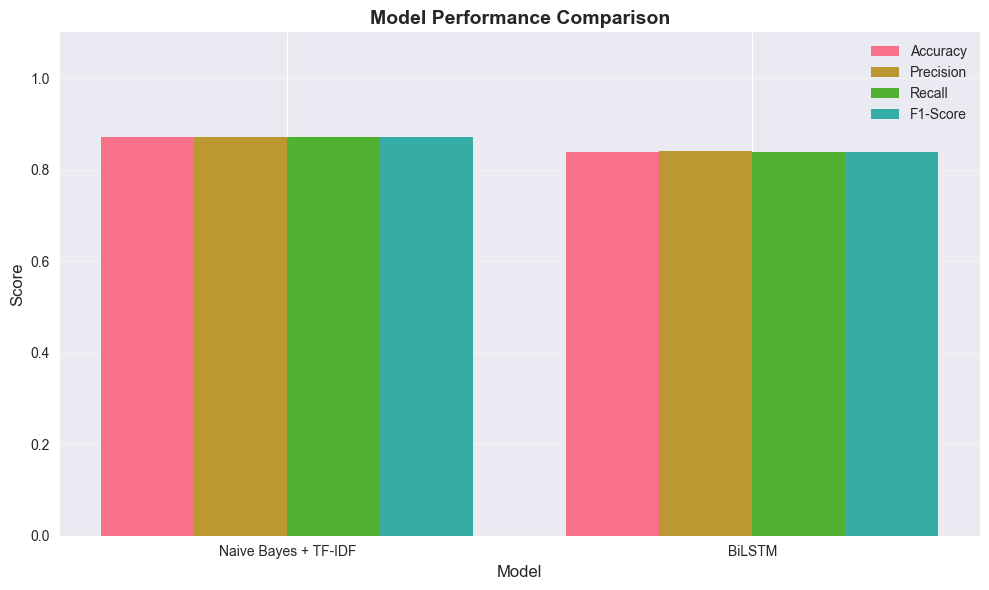

In [10]:
# 1. Metrics comparison bar plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(x + offset, comparison_df[metric], width, label=metric)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_metrics.png", dpi=300, bbox_inches='tight')
plt.show()


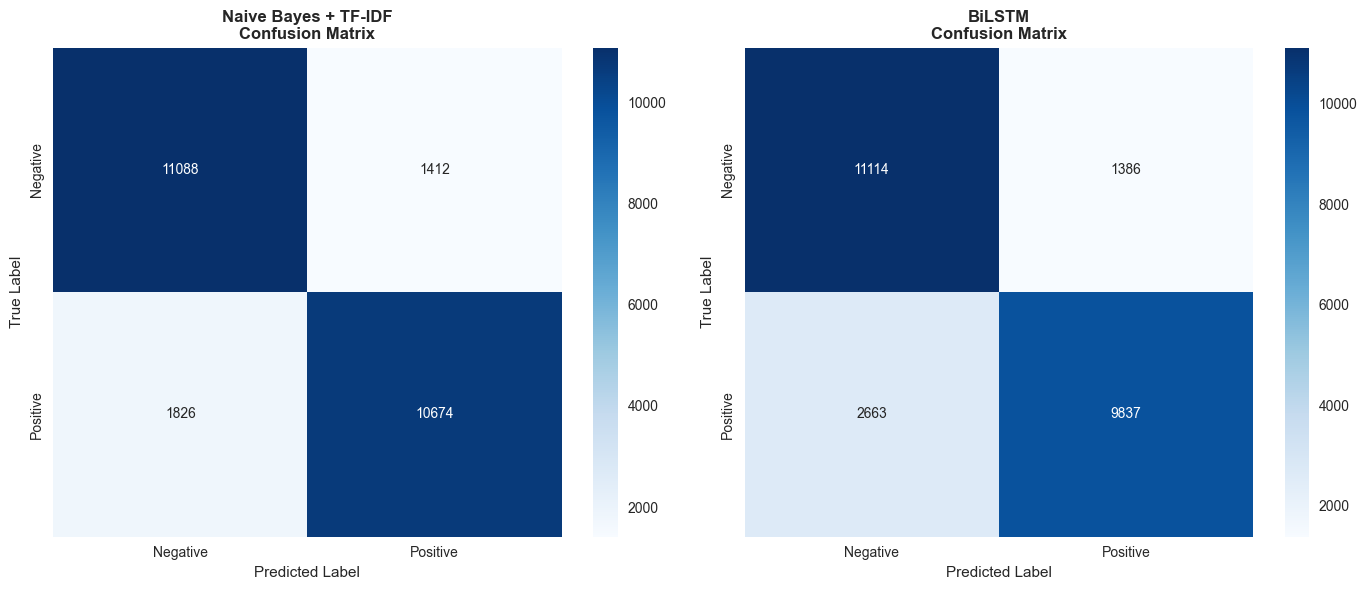

In [11]:
# 2. Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Naive Bayes
sns.heatmap(nb_metrics["confusion_matrix"], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_title('Naive Bayes + TF-IDF\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# LSTM
sns.heatmap(lstm_metrics["confusion_matrix"], annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('BiLSTM\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


## 4.4 Fehleranalyse


In [12]:
# Find disagreements between models
nb_df["model"] = "NB"
lstm_df["model"] = "LSTM"

# Merge on index to compare predictions
merged = pd.merge(
    nb_df[["y_true", "y_pred"]].reset_index(),
    lstm_df[["y_pred"]].reset_index(),
    left_index=True, right_index=True,
    suffixes=("_nb", "_lstm")
)

# Find cases where models disagree
disagreements = merged[merged["y_pred_nb"] != merged["y_pred_lstm"]]
print(f"Number of disagreements: {len(disagreements)} ({len(disagreements)/len(merged)*100:.2f}%)")

# Find cases where both are wrong
both_wrong = merged[
    (merged["y_pred_nb"] != merged["y_true"]) & 
    (merged["y_pred_lstm"] != merged["y_true"])
]
print(f"Both models wrong: {len(both_wrong)} ({len(both_wrong)/len(merged)*100:.2f}%)")

# Find cases where one is right and other is wrong
nb_right_lstm_wrong = merged[
    (merged["y_pred_nb"] == merged["y_true"]) & 
    (merged["y_pred_lstm"] != merged["y_true"])
]
lstm_right_nb_wrong = merged[
    (merged["y_pred_lstm"] == merged["y_true"]) & 
    (merged["y_pred_nb"] != merged["y_true"])
]

print(f"\nNB correct, LSTM wrong: {len(nb_right_lstm_wrong)}")
print(f"LSTM correct, NB wrong: {len(lstm_right_nb_wrong)}")


Number of disagreements: 3681 (14.72%)
Both models wrong: 1803 (7.21%)

NB correct, LSTM wrong: 2246
LSTM correct, NB wrong: 1435


## 4.5 Interpretation und Diskussion

### Ergebnisse:

**Naive Bayes + TF-IDF:**
- Accuracy und F1-Score siehe Vergleichstabelle oben
- Vorteile: Schnelles Training, geringer Ressourcenbedarf, interpretierbar
- Nachteile: Ignoriert Wortreihenfolge, kann Negationen nicht gut modellieren

**BiLSTM:**
- Accuracy und F1-Score siehe Vergleichstabelle oben
- Vorteile: Erfasst Sequenzinformationen, kann komplexe Muster lernen
- Nachteile: Längeres Training, höherer Ressourcenbedarf

### Vergleich:

Die Ergebnisse zeigen, welches Modell in diesem Lauf besser performt. BiLSTM kann Sequenzinformationen erfassen (z.B. "not good"), während TF-IDF+NB nur Bag-of-Words ohne Sequenz erfasst. TF-IDF+NB ist jedoch deutlich schneller im Training.


## 4.6 Real-World Anwendungen

**Sentiment-Analyse** hat viele praktische Anwendungen:

1. **E-Commerce**: Automatische Bewertung von Produktreviews
2. **Social Media Monitoring**: Tracking von Marken-Sentiment in sozialen Medien
3. **Customer Service**: Priorisierung von Beschwerden basierend auf Sentiment
4. **Market Research**: Analyse von Kundenfeedback und Meinungen
5. **Content Moderation**: Erkennung von negativen/hassfülligen Inhalten

**IMDB Reviews** sind besonders relevant für:
- Filmstudios zur Analyse von Publikumsreaktionen
- Streaming-Plattformen zur Empfehlungssystemen
- Filmkritiker zur Trendanalyse
